In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn import tree
import optuna
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

p:\Python\ML1\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def sklearn_metric_printer(y_test, y_pred, model_name="Model"):
    print(f"\n--- {model_name} ---")
    print(f'MAE:  {mean_absolute_error(y_test, y_pred):.4f}')
    print(f'MSE:  {mean_squared_error(y_test, y_pred):.4f}')
    print(f'RMSE: {math.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
    print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred):.4f}')
    print(f'R²:   {r2_score(y_test, y_pred):.4f}')

In [4]:
def plotter(y_test, y_pred, model_name="Model"):
    errors = y_test - y_pred
    plt.figure(figsize=(8, 4))
    sns.histplot(errors, kde=True, bins=30, color='purple')
    plt.title(f'Распределение ошибок: {model_name}')
    plt.xlabel('Ошибка (y_true - y_pred)')
    plt.ylabel('Количество')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    sns.kdeplot(y_test, label='Actual', color='red')
    sns.kdeplot(y_pred, label='Predicted', color='blue')
    plt.title(f'Сравнение распределений: {model_name}')
    plt.xlabel('Значение')
    plt.ylabel('Плотность')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [5]:
data = pd.read_csv('data/r5_eda.csv')

In [6]:
y = data['quality']
X = data.drop('quality', axis=1)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### DecisionTreeRegressor

In [92]:
reg = DecisionTreeRegressor(max_depth=6)
reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=6)

In [93]:
y_pred = reg.predict(X_test)
sklearn_metric_printer(y_test, y_pred, model_name="DecisionTreeRegressor")


--- DecisionTreeRegressor ---
MAE:  0.5764
MSE:  0.5481
RMSE: 0.7403
MAPE: 0.1023
R²:   0.3051


#### Подбор гиперпараметров

In [94]:
def objective(trial):
    max_depth = trial.suggest_int('max_depth', 1, 32)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features = trial.suggest_categorical('max_features', [None, 'sqrt', 'log2'])
    
    model = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42
    )
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    return -scores.mean()

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=50)

In [95]:
# reg = DecisionTreeRegressor(**study.best_params, random_state=42)
reg = DecisionTreeRegressor(max_depth=7, min_samples_leaf=17, min_samples_split=6,
                      random_state=42)
reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=7, min_samples_leaf=17, min_samples_split=6,
                      random_state=42)


--- DecisionTreeRegressor ---
MAE:  0.5688
MSE:  0.5327
RMSE: 0.7299
MAPE: 0.1008
R²:   0.3246


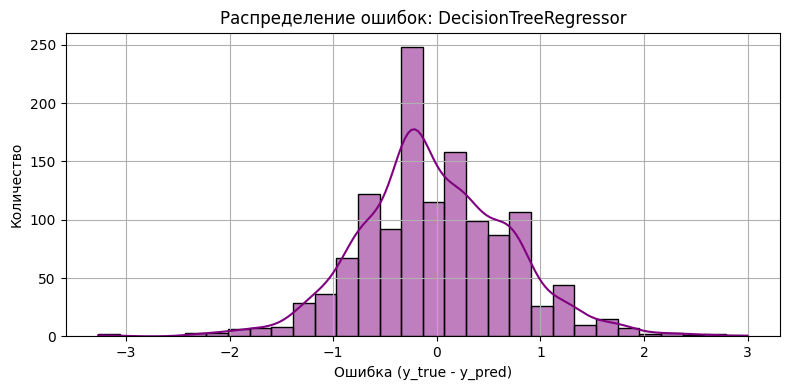

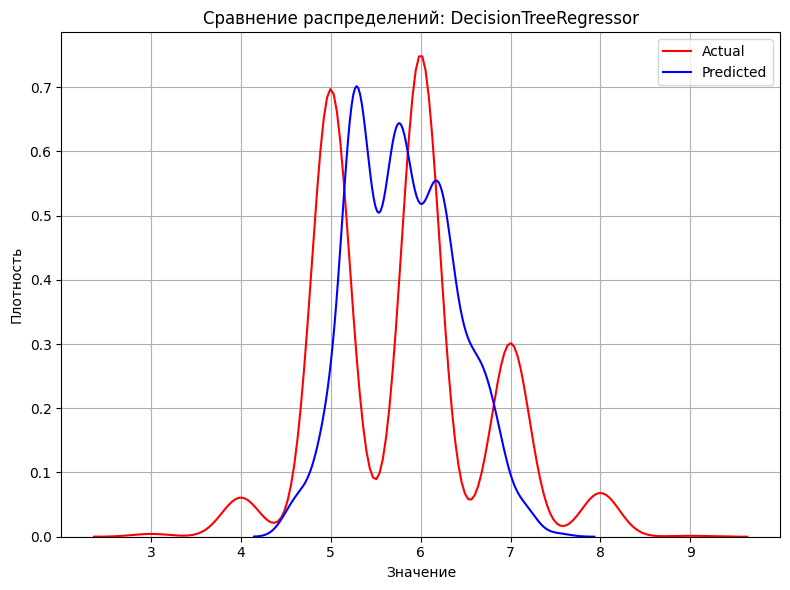

In [96]:
y_pred = reg.predict(X_test)
sklearn_metric_printer(y_test, y_pred, model_name="DecisionTreeRegressor")
plotter(y_test, y_pred, model_name="DecisionTreeRegressor")

### BaggingRegressor

In [97]:
base_regressor = DecisionTreeRegressor(max_depth=6)

bg_reg = BaggingRegressor(
    estimator=base_regressor,
    n_estimators=100,
    random_state=42
)

bg_reg.fit(X_train, y_train)

BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=6), n_estimators=100,
                 random_state=42)

In [98]:
y_pred = bg_reg.predict(X_test)
sklearn_metric_printer(y_test, y_pred, model_name="BaggingRegressor")


--- BaggingRegressor ---
MAE:  0.5423
MSE:  0.4781
RMSE: 0.6915
MAPE: 0.0963
R²:   0.3938


#### Подбор гиперпараметров

In [99]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 10, 200)
    max_samples = trial.suggest_float('max_samples', 0.1, 1.0)
    max_features = trial.suggest_float('max_features', 0.1, 1.0)
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    
    model = BaggingRegressor(
        n_estimators=n_estimators,
        max_samples=max_samples,
        max_features=max_features,
        bootstrap=bootstrap,
        random_state=42
    )
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    return -scores.mean()

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=50)

In [100]:
# bg_reg = BaggingRegressor(**study.best_params, random_state=42)
bg_reg = BaggingRegressor(bootstrap=False, max_features=0.8155447145017635,
                 max_samples=0.824318215106522, n_estimators=193,
                 random_state=42)
bg_reg.fit(X_train, y_train)

BaggingRegressor(bootstrap=False, max_features=0.8155447145017635,
                 max_samples=0.824318215106522, n_estimators=193,
                 random_state=42)


--- BaggingRegressor ---
MAE:  0.3961
MSE:  0.3383
RMSE: 0.5817
MAPE: 0.0712
R²:   0.5711


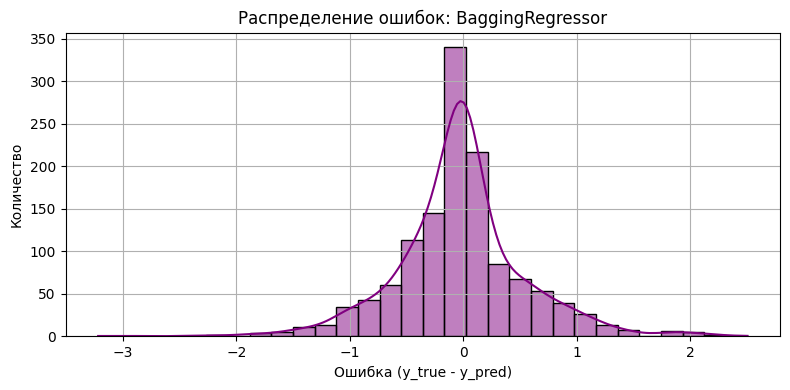

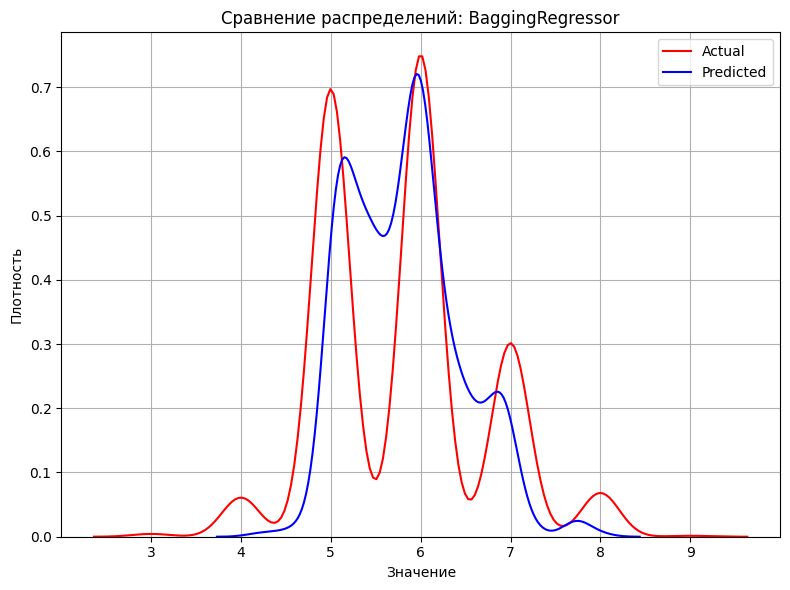

In [101]:
y_pred = bg_reg.predict(X_test)
sklearn_metric_printer(y_test, y_pred, model_name="BaggingRegressor")
plotter(y_test, y_pred, model_name="BaggingRegressor")

### GradientBoostingRegressor

In [102]:
gb_reg = GradientBoostingRegressor(max_depth=6, n_estimators=100, random_state=42)
gb_reg.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=6, random_state=42)

In [103]:
y_pred = gb_reg.predict(X_test)
sklearn_metric_printer(y_test, y_pred, model_name="")


---  ---
MAE:  0.4816
MSE:  0.4072
RMSE: 0.6381
MAPE: 0.0856
R²:   0.4837


#### Подбор гиперпараметров

In [104]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    max_depth = trial.suggest_int('max_depth', 1, 10)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    
    model = GradientBoostingRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        subsample=subsample,
        random_state=42
    )
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    return -scores.mean()

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=50)

In [105]:
# gb_reg = GradientBoostingRegressor(**study.best_params, random_state=42)
gb_reg = GradientBoostingRegressor(learning_rate=0.07702481201263307, max_depth=10,
                          min_samples_leaf=4, min_samples_split=18,
                          n_estimators=199, random_state=42,
                          subsample=0.656550698796666)
gb_reg.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.07702481201263307, max_depth=10,
                          min_samples_leaf=4, min_samples_split=18,
                          n_estimators=199, random_state=42,
                          subsample=0.656550698796666)


--- GradientBoostingRegressor ---
MAE:  0.4120
MSE:  0.3574
RMSE: 0.5979
MAPE: 0.0739
R²:   0.5468


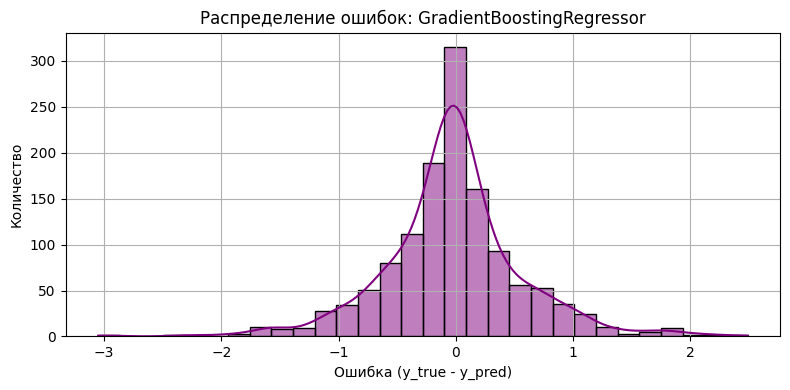

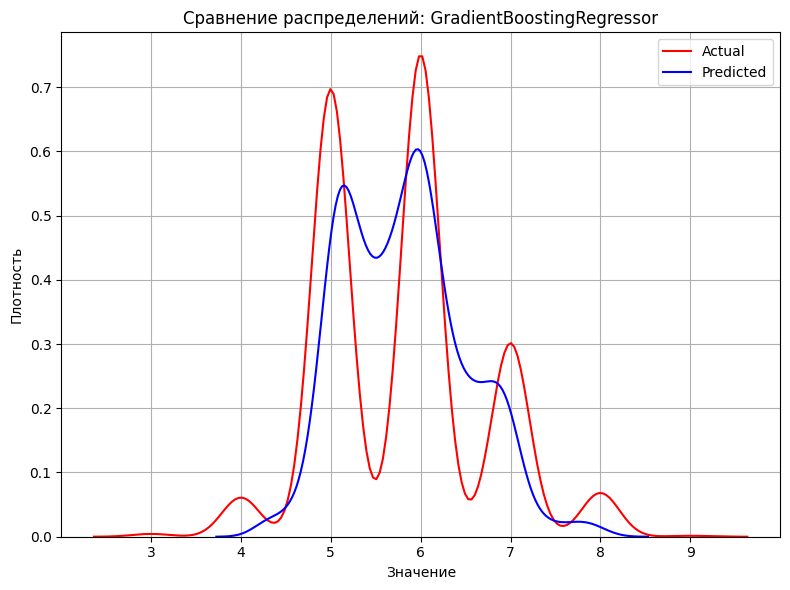

In [106]:
y_pred = gb_reg.predict(X_test)
sklearn_metric_printer(y_test, y_pred, model_name="GradientBoostingRegressor")
plotter(y_test, y_pred, model_name="GradientBoostingRegressor")

### StackingRegressor

In [107]:
estimators = [
    ('dt', DecisionTreeRegressor(max_depth=3)),
    ('lr', LinearRegression())
]

stack_reg = StackingRegressor(estimators=estimators, final_estimator=LinearRegression())
stack_reg.fit(X_train, y_train)

StackingRegressor(estimators=[('dt', DecisionTreeRegressor(max_depth=3)),
                              ('lr', LinearRegression())],
                  final_estimator=LinearRegression())

In [108]:
y_pred = stack_reg.predict(X_test)
sklearn_metric_printer(y_test, y_pred, model_name="StackingRegressor")


--- StackingRegressor ---
MAE:  0.5692
MSE:  0.5346
RMSE: 0.7312
MAPE: 0.1009
R²:   0.3222


#### Подбор гиперпараметров

In [109]:
def objective(trial):
    dt_max_depth = trial.suggest_int('dt_max_depth', 1, 10)
    dt_min_samples_split = trial.suggest_int('dt_min_samples_split', 2, 20)
    alpha = trial.suggest_float('alpha', 0.1, 10.0)
    
    estimators = [
        ('dt', DecisionTreeRegressor(max_depth=dt_max_depth, min_samples_split=dt_min_samples_split, random_state=42)),
        ('lr', LinearRegression())
    ]
    meta_model = Ridge(alpha=alpha, random_state=42)
    
    model = StackingRegressor(estimators=estimators, final_estimator=meta_model)
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    return -scores.mean()

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=50)

In [110]:
# best_params = study.best_params
best_estimators = [
    # ('dt', DecisionTreeRegressor(
    #     max_depth=best_params['dt_max_depth'], min_samples_split=best_params['dt_min_samples_split'], random_state=42)),
    ('dt', DecisionTreeRegressor(max_depth=10, min_samples_split=15, random_state=42)),
    ('lr', LinearRegression())
]
# best_meta_model = Ridge(alpha=best_params['alpha'], random_state=42)
best_meta_model = Ridge(alpha=9.494307568806033, random_state=42)
stack_reg = StackingRegressor(
    estimators=best_estimators, final_estimator=best_meta_model)
stack_reg.fit(X_train, y_train)

StackingRegressor(estimators=[('dt',
                               DecisionTreeRegressor(max_depth=10,
                                                     min_samples_split=15,
                                                     random_state=42)),
                              ('lr', LinearRegression())],
                  final_estimator=Ridge(alpha=9.494307568806033,
                                        random_state=42))


--- StackingRegressor ---
MAE:  0.5502
MSE:  0.4976
RMSE: 0.7054
MAPE: 0.0979
R²:   0.3691


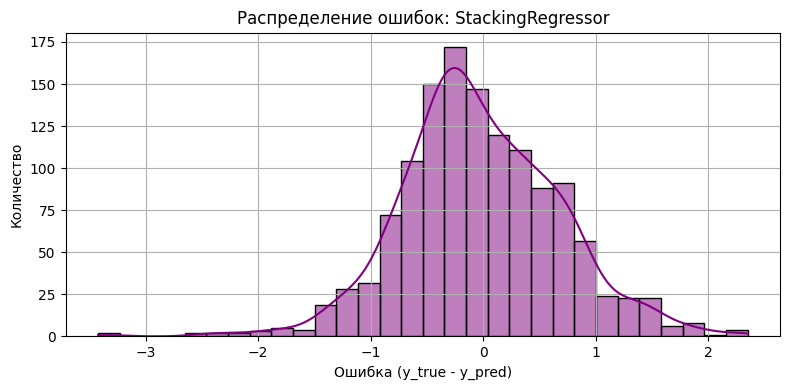

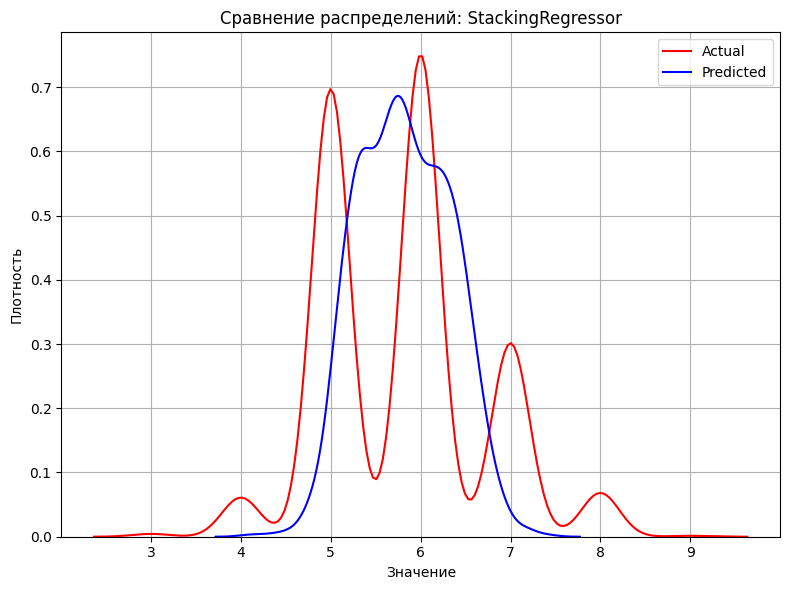

In [111]:
y_pred = stack_reg.predict(X_test)
sklearn_metric_printer(y_test, y_pred, model_name="StackingRegressor")
plotter(y_test, y_pred, model_name="StackingRegressor")

### CatBoostRegressor

In [112]:
cat_model = CatBoostRegressor(
    max_depth=3,
    n_estimators=100,
    learning_rate=0.1,
    random_seed=42,
    verbose=0
)
cat_model.fit(X_train, y_train)

In [113]:
y_pred = cat_model.predict(X_test)
sklearn_metric_printer(y_test, y_pred, model_name="CatBoostRegressor")


--- CatBoostRegressor ---
MAE:  0.5459
MSE:  0.4801
RMSE: 0.6929
MAPE: 0.0965
R²:   0.3913


#### Подбор гиперпараметров

In [114]:
def objective(trial):
    iterations = trial.suggest_int('iterations', 50, 300)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    depth = trial.suggest_int('depth', 1, 10)
    l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 1, 10)
    bagging_temperature = trial.suggest_float('bagging_temperature', 0, 1)
    
    model = CatBoostRegressor(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        l2_leaf_reg=l2_leaf_reg,
        bagging_temperature=bagging_temperature,
        random_seed=42,
        verbose=0
    )
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    return -scores.mean()

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=50)

In [115]:
# cat_model = CatBoostRegressor(**study.best_params, random_seed=42, verbose=0)
cat_model = CatBoostRegressor(iterations=239, learning_rate=0.1735670585336696, depth=10,
                              l2_leaf_reg=1.5575204985618745, bagging_temperature=0.9612943749961429, random_seed=42, verbose=0)
cat_model.fit(X_train, y_train)


--- Model ---
MAE:  0.4203
MSE:  0.3559
RMSE: 0.5966
MAPE: 0.0753
R²:   0.5487


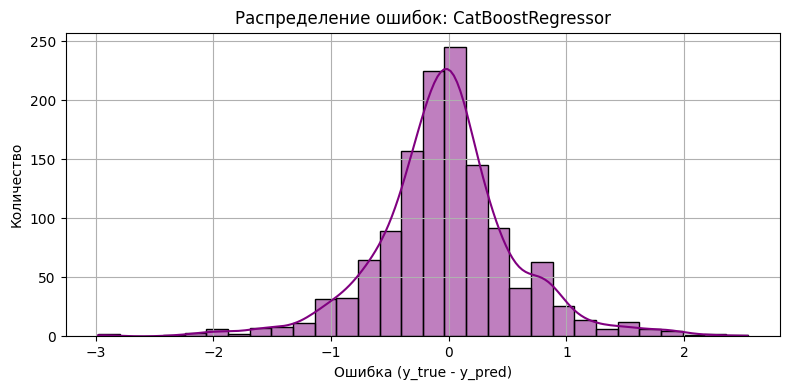

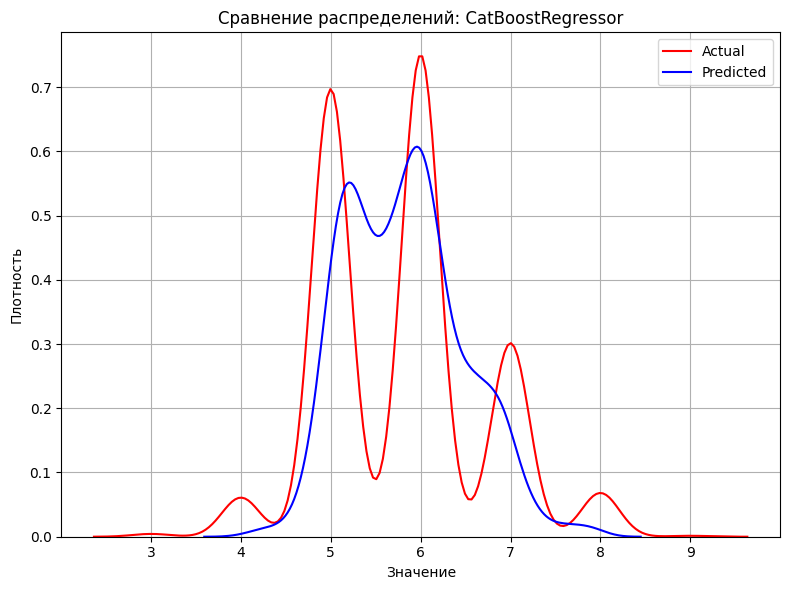

In [116]:
y_pred = cat_model.predict(X_test)
sklearn_metric_printer(y_test, y_pred)
plotter(y_test, y_pred, model_name="CatBoostRegressor")

### XGBRegressor

In [117]:
xgb_model = XGBRegressor(
    max_depth=3,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [118]:
y_pred = xgb_model.predict(X_test)
sklearn_metric_printer(y_test, y_pred, model_name="XGBRegressor")


--- XGBRegressor ---
MAE:  0.5290
MSE:  0.4586
RMSE: 0.6772
MAPE: 0.0935
R²:   0.4186


#### Подбор гиперпараметров

In [119]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 1, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
    gamma = trial.suggest_float('gamma', 0, 5)
    reg_alpha = trial.suggest_float('reg_alpha', 0, 10)
    reg_lambda = trial.suggest_float('reg_lambda', 0, 10)
    
    model = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        verbosity=0
    )
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    return -scores.mean()

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=50)

In [120]:
# xgb_model = XGBRegressor(**study.best_params, random_state=42, verbosity=0)
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8721386921131723, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.01172749841706952, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.16879509767187384,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=9, max_leaves=None,
             min_child_weight=None, monotone_constraints=None,
             multi_strategy=None, n_estimators=113, n_jobs=None,
             num_parallel_tree=None)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)


--- XGBRegressor ---
MAE:  0.5290
MSE:  0.4586
RMSE: 0.6772
MAPE: 0.0935
R²:   0.4186


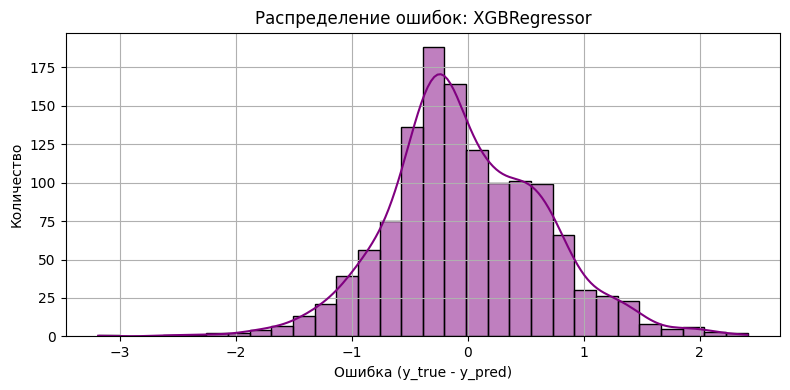

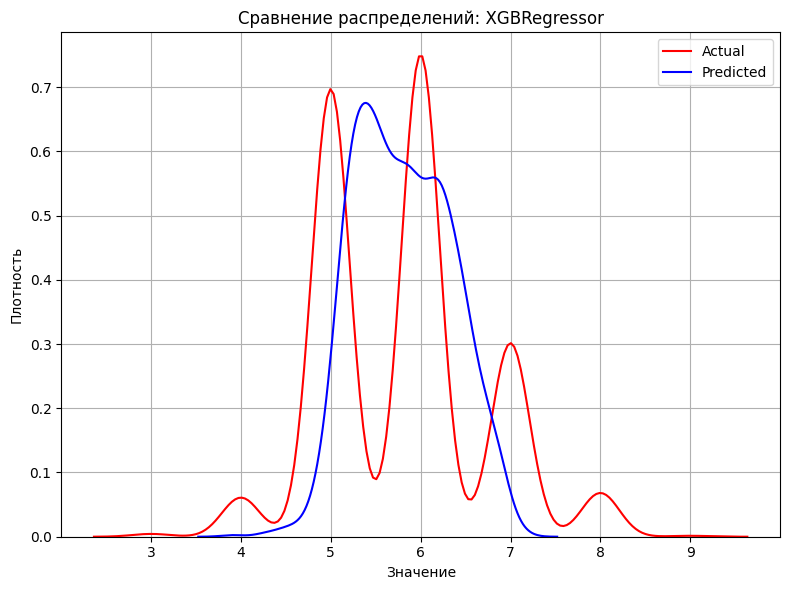

In [121]:
y_pred = xgb_model.predict(X_test)
sklearn_metric_printer(y_test, y_pred, model_name="XGBRegressor")
plotter(y_test, y_pred, model_name="XGBRegressor")

### LGBMRegressor

In [122]:
lgb_model = LGBMRegressor(
    max_depth=3,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train, y_train)

LGBMRegressor(max_depth=3, random_state=42, verbose=-1)

In [123]:
y_pred = lgb_model.predict(X_test)
sklearn_metric_printer(y_test, y_pred, model_name="LGBMRegressor")


--- LGBMRegressor ---
MAE:  0.5299
MSE:  0.4612
RMSE: 0.6791
MAPE: 0.0937
R²:   0.4153


#### Подбор гиперпараметров

In [124]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 1, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    num_leaves = trial.suggest_int('num_leaves', 2, 100)
    min_child_samples = trial.suggest_int('min_child_samples', 1, 20)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
    reg_alpha = trial.suggest_float('reg_alpha', 0, 10)
    reg_lambda = trial.suggest_float('reg_lambda', 0, 10)
    
    model = LGBMRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        min_child_samples=min_child_samples,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        seed=42,
        verbosity=-1
    )
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    return -scores.mean()

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=50)

In [125]:
# lgb_model = LGBMRegressor(**study.best_params, seed=42, verbosity=-1)
lgb_model = LGBMRegressor(colsample_bytree=0.6874177897610134,
                          learning_rate=0.10164989726296375, max_depth=10,
                          min_child_samples=2, n_estimators=264, num_leaves=90,
                          reg_alpha=2.031151025888943, reg_lambda=1.558470976440029,
                          seed=42, subsample=0.5829880385491577, verbosity=-1)
lgb_model.fit(X_train, y_train)

LGBMRegressor(colsample_bytree=0.6874177897610134,
              learning_rate=0.10164989726296375, max_depth=10,
              min_child_samples=2, n_estimators=264, num_leaves=90,
              reg_alpha=2.031151025888943, reg_lambda=1.558470976440029,
              seed=42, subsample=0.5829880385491577, verbosity=-1)


--- Model ---
MAE:  0.4222
MSE:  0.3513
RMSE: 0.5927
MAPE: 0.0754
R²:   0.5546


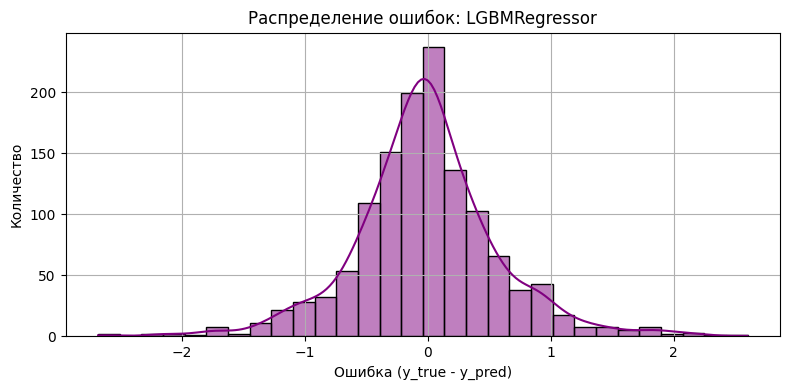

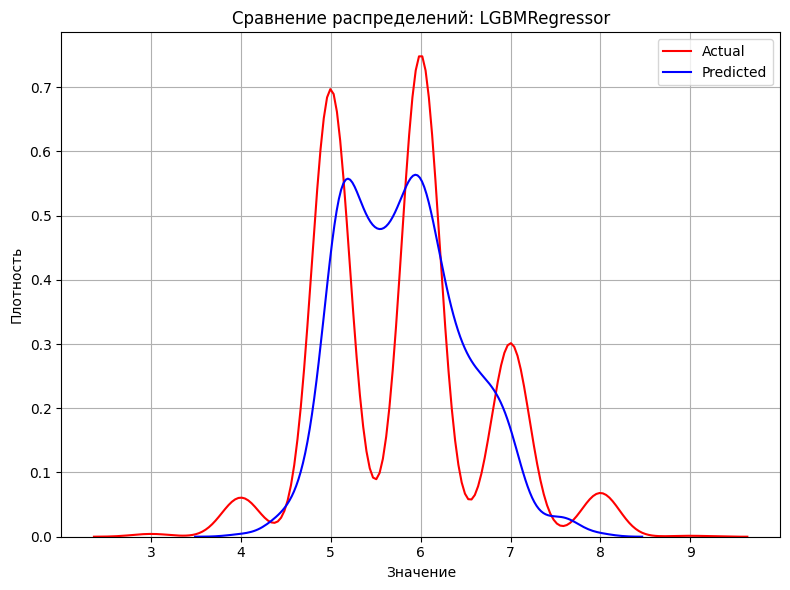

In [126]:
y_pred = lgb_model.predict(X_test)
sklearn_metric_printer(y_test, y_pred)
plotter(y_test, y_pred, model_name="LGBMRegressor")

Все модели

In [127]:
models = [reg, bg_reg, gb_reg, stack_reg, cat_model, xgb_model, lgb_model]

In [128]:
model_names = [
    'Decision Tree Regressor',
    'Bagging Regressor',
    'Gradient Boosting Regressor',
    'Stacking Regressor',
    'CatBoost Regressor',
    'XGBoost Regressor',
    'LightGBM Regressor'
]

Таблица сравнения:
                         Model       MSE      RMSE        R2
1            Bagging Regressor  0.338318  0.581651  0.571055
6           LightGBM Regressor  0.351325  0.592726  0.554564
4           CatBoost Regressor  0.355928  0.596597  0.548728
2  Gradient Boosting Regressor  0.357443  0.597865  0.546808
5            XGBoost Regressor  0.458569  0.677178  0.418591
3           Stacking Regressor  0.497593  0.705403  0.369114
0      Decision Tree Regressor  0.532713  0.729872  0.324586


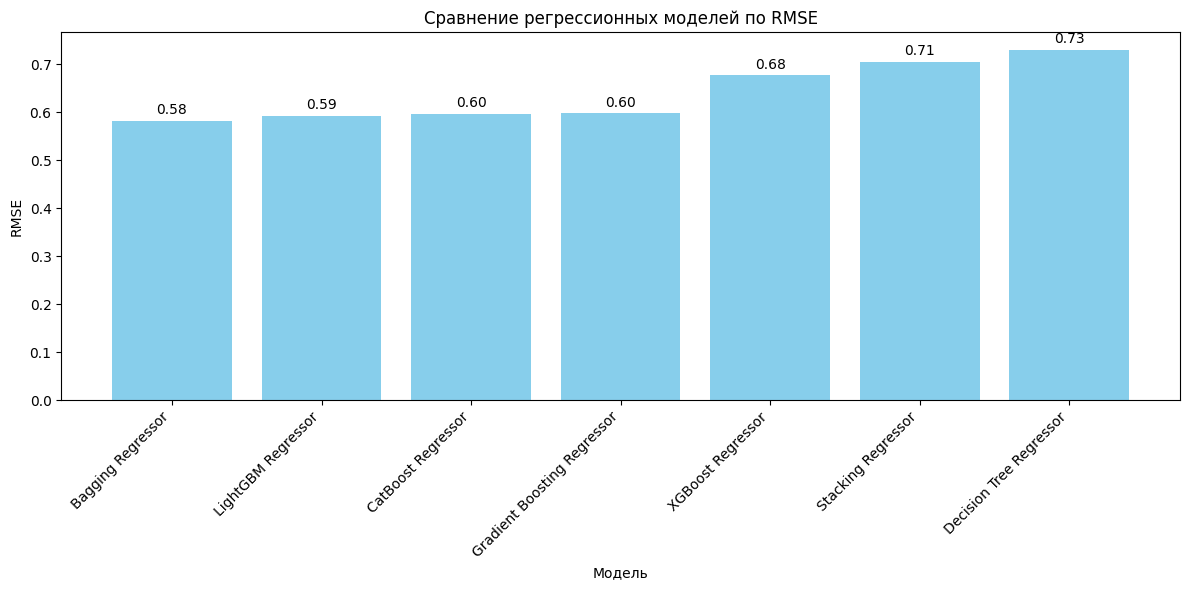

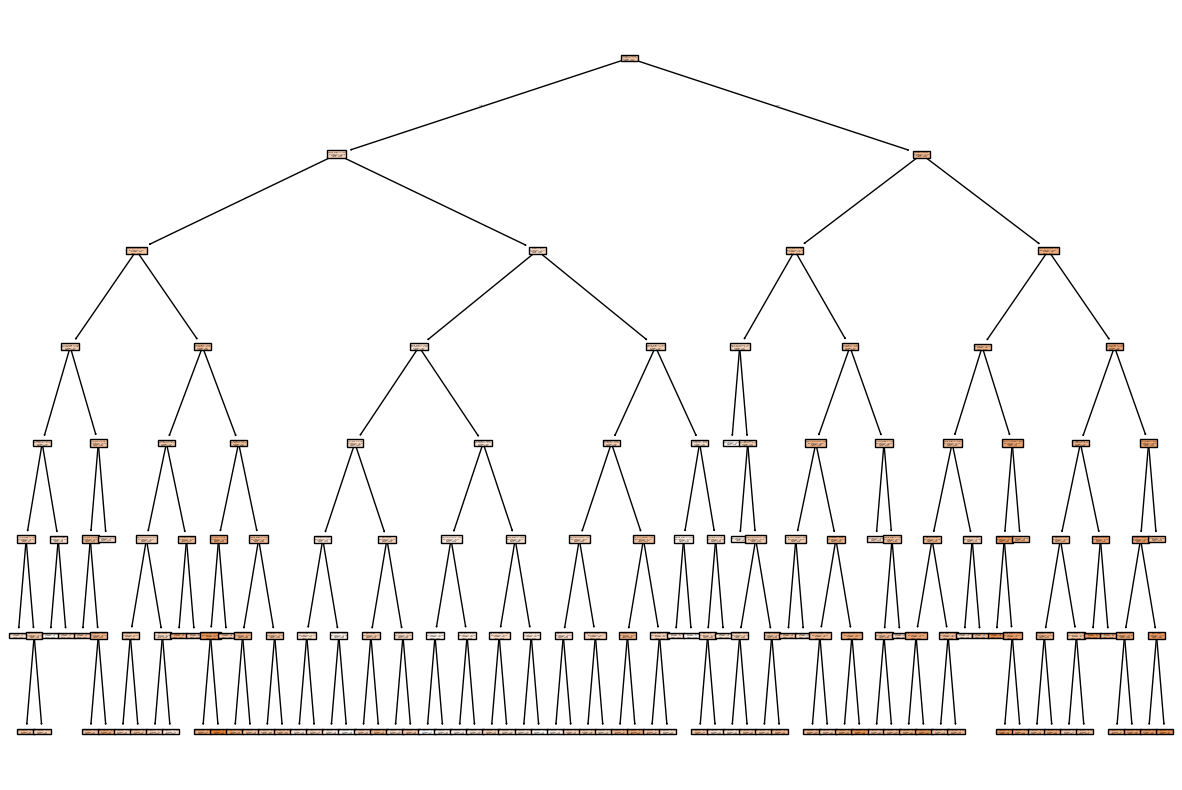

In [129]:
results = []
for model, name in zip(models, model_names):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'MSE': mse, 'RMSE': rmse, 'R2': r2})

df = pd.DataFrame(results)
df = df.sort_values(by='RMSE')

print("Таблица сравнения:")
print(df)

plt.figure(figsize=(12, 6))
plt.bar(df['Model'], df['RMSE'], color='skyblue')
plt.xlabel('Модель')
plt.ylabel('RMSE')
plt.title('Сравнение регрессионных моделей по RMSE')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(df['RMSE']):
    plt.text(i, v + 0.01 * max(df['RMSE']), f'{v:.2f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(15,10))
DT_plot = tree.plot_tree(reg, feature_names=X_train.columns, filled=True)


--- Model ---
MAE:  0.5054
MSE:  0.6438
RMSE: 0.8024
MAPE: 0.0890
R²:   0.1725


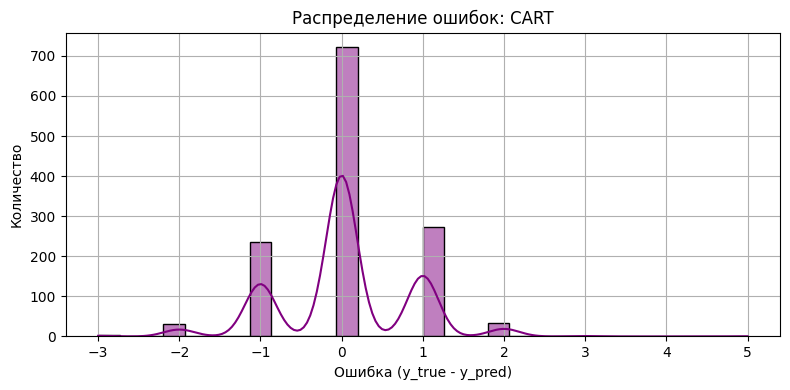

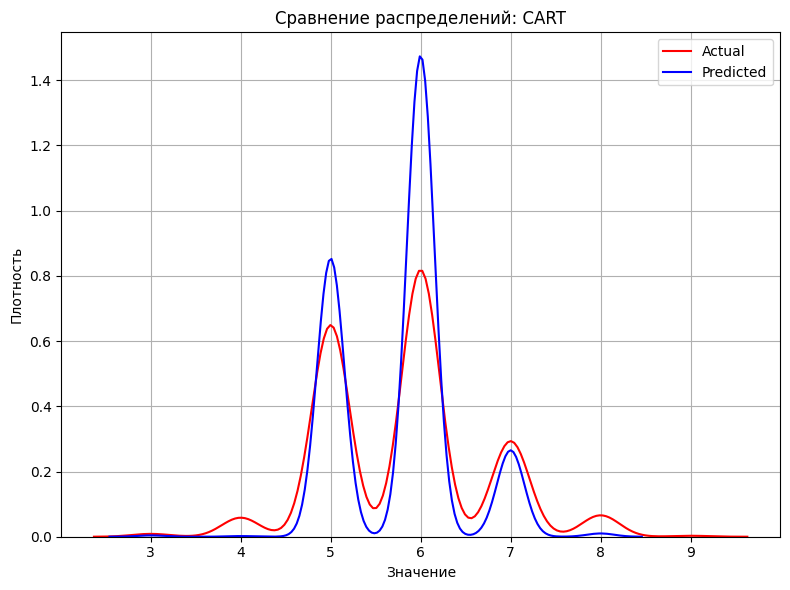

In [12]:
from cart import DecisionTree

# X_train = X_train.to_numpy()
# X_test = X_test.to_numpy()

tree = DecisionTree(max_depth=6)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
sklearn_metric_printer(y_test, y_pred)
plotter(y_test, y_pred, model_name="CART")